In [1]:
#def get_obs_id_from_h5dl1_file(h5dl1InName):
#"/dl1/event/telescope/parameters/tel_001"
#col name is obs_id
#print(h5file)
#print(table)
#print(table[:]['energy'])
#print("for node in h5file")
#for node in h5file:
#print(node)
#h5file = open_file(h5dl1InName, "a")
#table = h5file.root.dl1.event.telescope.parameters.tel_001
#obs_id=int(np.mean(table[:]['obs_id']))
#obs_id_std=np.std(table[:]['obs_id'])
#print(obs_id)
#print(np.std(table[:]['obs_id']))
#h5file.close()
#if (obs_id_std == 0.0) :
#return obs_id
#return -999
#
import pandas as pd
import numpy as np
import glob
import gc
import matplotlib.pyplot as plt
from matplotlib import colors
from astropy.coordinates import SkyCoord, AltAz, angular_separation
import astropy.units as u
from scipy.stats import binned_statistic
from scipy.signal import lombscargle
import h5py
from astropy.io import fits
from astropy.table import Table
from tables import open_file

from astropy.table import join, vstack
from ctapipe.io import read_table 

from ctapipe.instrument import SubarrayDescription
from matplotlib.colors import LogNorm


import math

In [2]:
subarr=SubarrayDescription.read(
        "dataset://gamma_prod5.simtel.zst",
        focal_length_choice="EQUIVALENT")

In [3]:
#SST-1M DigiCam (corsika_theta_20.0_az_180.0_run10.simtel.gz)
#geom = subarr.tel[4].camera.geometry
#optics = subarr.tel[4].optics

#Mace (corsika_theta_20.0_az_180.0_run10.simtel.gz)
#geom = subarr.tel[1].camera.geometry
#optics = subarr.tel[1].optics


#LST LSTCam
geom = subarr.tel[1].camera.geometry
optics = subarr.tel[1].optics
#MST FlashCam
#geom = subarr.tel[5].camera.geometry
#optics = subarr.tel[5].optics
#MST NectarCam
#geom = subarr.tel[100].camera.geometry
#optics = subarr.tel[100].optics
#SST CHEC
#geom = subarr.tel[60].camera.geometry
#optics = subarr.tel[60].optics

#geom = subarr.tel[50].camera.geometry

#geom = subarr.tel[8].camera.geometry
#def prod5_mst_flashcam(subarray_prod5_paranal):
#    return subarray_prod5_paranal.tel[5]
#def prod5_mst_nectarcam(subarray_prod5_paranal):
#    return subarray_prod5_paranal.tel[100]
#def prod5_lst(subarray_prod5_paranal):
#    return subarray_prod5_paranal.tel[1]
#def prod5_sst(subarray_prod5_paranal):
#    return subarray_prod5_paranal.tel[60]

In [4]:
from ctapipe.visualization import CameraDisplay

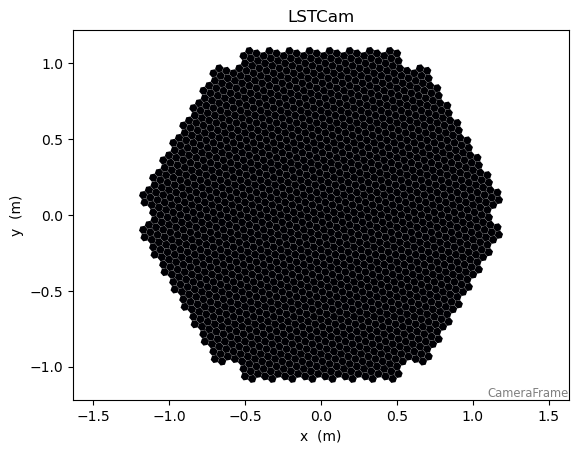

In [5]:
disp = CameraDisplay(geom)

In [6]:
h5file=open_file("data/muon-_0deg_0deg_run000003___cta-prod6-2147m-Paranal-lst-dark-ref-degraded-0.8.h5", "a")
#h5file=open_file("data/test/muon-_0deg_0deg_run000002___cta-prod6-2147m-Paranal-mst-nc-dark-ref-degraded-0.8.h5", "a")
#h5file=open_file("/home/burmist/Downloads/muon-_0deg_0deg_run000001___cta-prod6-2147m-Paranal-mst-nc-dark-ref-degraded-0.8.simtel.zst", "a")
#h5file=open_file("./data/data_muon_verticle_no_magnetic_field/muon-_0deg_0deg_run000001___cta-prod6-2147m-Paranal-mst-nc-dark-ref-degraded-0.8.h5", "a")

In [7]:
h5file.root.dl1.event.telescope.images.tel_001[:]

array([(3,     100, 1, [ 31,  11,  -4, ...,  21,  11,  40], [1249,  988, 1396, ..., 1286,  983, 1178], [False, False, False, ..., False, False, False],  True),
       (3,     200, 1, [-20, -10,  -1, ...,  15, -12, -15], [1278, 1006, 1052, ..., 1386, 1622, 1211], [False, False, False, ..., False, False, False],  True),
       (3,     300, 1, [ 28,  12,   8, ..., -19,  -1, -18], [1224, 1360, 1322, ..., 1235, 1432, 1211], [False, False, False, ..., False, False, False],  True),
       ...,
       (3,  999800, 1, [  5,  -5,  10, ...,  36, -16,   2], [1293, 1065, 1299, ..., 1295, 1329, 1410], [False, False, False, ..., False, False, False],  True),
       (3,  999900, 1, [-12,  -8, -13, ...,  -4,   7,  -8], [1180, 1299, 1103, ..., 1341, 1059, 1504], [False, False, False, ..., False, False, False],  True),
       (3, 1000000, 1, [-17,   0, -14, ...,  -5,   0,   4], [1180, 1385,  810, ...,  942, 1407, 1004], [False, False, False, ..., False, False, False],  True)],
      shape=(9952,), dtype=

In [43]:
h5file.root.dl1.event.telescope.muon.tel_001[:]

array([(3,     100, 1, -0.22800969, -0.40310665, 1.28665611, 0.3448174 , 0.41479091, 0.40728441, -119.49385335, 0.46312351, 1., 0.26666667, 0.42892537, 0.01596016, 1311.9325, 6.491636,  73,  0.02051192, 0.07193298, -6.13067202e+01, -7.61593270e+02, 0.14823373, 14.95792709,  7.13136732, 13.14850497, 0.21851799, False, False, 2086.23570728),
       (3,     200, 1,  0.16336536,  0.36351603, 1.07520127, 0.25514053, 0.17217174, 0.19421752,   65.80068398, 0.39853751, 1., 0.66666667, 0.6823734 , 0.00459818, 2117.7275, 0.      , 103, -0.00178826, 0.04358525, -2.27030201e+02, -4.50191653e+03, 0.06803407,  9.04303908, -8.48703488, -3.1219857 , 0.19793774,  True, False, 1679.48721863),
       (3,     300, 1,  0.30708177, -0.54848772, 1.44367784, 0.26718428, 0.39282204, 0.34986094,  -60.75684856, 0.62860002, 1., 0.56666667, 0.461692  , 0.01175445, 1851.6377, 0.      ,  92,  0.15006055, 0.24188919, -2.60830003e+00, -7.98497398e-01, 0.1635042 , 10.71994916, -3.33778061, 10.18707664, 0.18807049,  Tru

In [36]:
delta_charge = -np.sum(h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][:],axis=1) + h5file.root.dl1.event.telescope.muon.tel_001[:]['muonparameters_ring_intensity'][:]

In [37]:
np.sum(h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][1])

np.int64(2162)

In [38]:
np.sum(h5file.root.dl1.event.telescope.images.tel_001[:]['image'][1])

np.int64(21362)

In [39]:
h5file.root.dl1.event.telescope.muon.tel_001[:]['muonparameters_ring_intensity'][:]

array([1311.9325, 2117.7275, 1851.6377, ..., 2307.616 , 2537.1074,
       2449.9146], shape=(9952,), dtype=float32)

(array([  1.,   1.,   0.,   2.,   2.,   1.,   1.,   3.,   2.,   1.,   1.,
          1.,   1.,   1.,   2.,   2.,   3.,   2.,   2.,   3.,   2.,   3.,
          4.,   5.,   4.,   1.,   2.,   5.,   2.,   1.,   2.,   5.,   9.,
          4.,   2.,   9.,   5.,   3.,   3.,   4.,   8.,  10.,   8.,   6.,
         11.,   8.,  18.,  14.,  10.,  17.,  28.,  22.,  30.,  30.,  29.,
         34.,  30.,  42.,  50.,  38.,  44.,  47.,  50.,  49.,  53.,  78.,
         80.,  63.,  86.,  85.,  99., 108.,  98., 121., 109., 123., 133.,
        135., 144., 169., 178., 162., 156., 177., 131., 186., 185., 201.,
        206., 194., 170., 198., 209., 175., 177., 197., 201., 194., 204.,
        185., 196., 187., 171., 171., 169., 162., 146., 153., 153., 139.,
        150., 120., 125., 111., 109., 101.,  97.,  90.,  96.,  79.,  76.,
         69.,  58.,  54.,  47.,  49.,  51.,  47.,  30.,  37.,  30.,  23.,
         21.,  23.,  24.,  17.,  15.,  15.,  11.,  13.,   9.,   5.,   9.,
          9.,   8.,   4.,   3.,   2., 

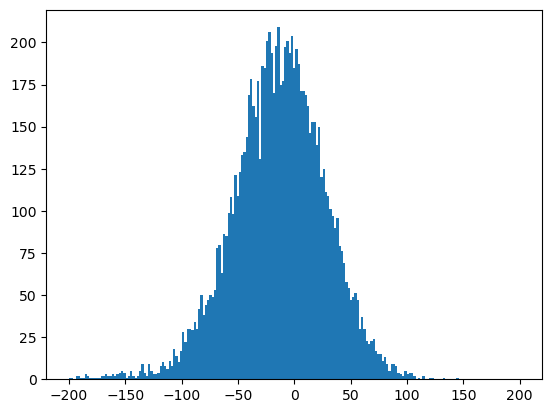

In [40]:
plt.hist(delta_charge,
        bins=np.linspace(-200, 200, 200))

In [41]:
np.nanmean(delta_charge)

np.float64(-49.28157634550682)

In [42]:
np.nanstd(delta_charge)

np.float64(457.1335819311808)

In [9]:
h5file.root.simulation.event.subarray.shower[:]['true_core_y'][0]

np.float64(-0.979865312576294)

In [54]:
np.sum(h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][:],axis=1)

array([1387, 2162, 2040, ..., 2375, 2545, 2436], shape=(9952,))

In [55]:
#plt.hist(h5file.root.dl1.event.telescope.muon.tel_001[:]['muonparameters_intensity_outside_ring'][:],
#        bins=np.linspace(-1,1,200));

In [57]:
image_int=np.sum(h5file.root.dl1.event.telescope.images.tel_001[:]['image'][:],axis=1)

h5file.root.dl1.event.telescope.muon.tel_001[:]['muonparameters_ring_intensity'][:]

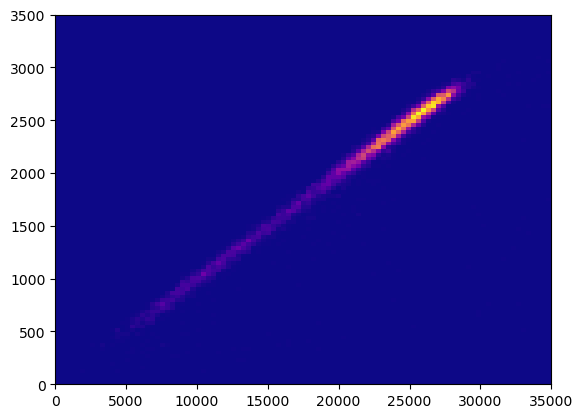

In [69]:
plt.hist2d(
    np.sum(h5file.root.dl1.event.telescope.images.tel_001[:]['image'][:],axis=1),
    h5file.root.dl1.event.telescope.muon.tel_001[:]['muonparameters_ring_intensity'][:],
    bins=[
        np.linspace( 0, 35000, 100), 
        np.linspace( 0, 3500, 100),
    ],
    cmap='plasma',
);

In [67]:
delta_reco_charge=np.sum(h5file.root.dl1.event.telescope.images.tel_001[:]['image'][:],axis=1)/10 - h5file.root.dl1.event.telescope.muon.tel_001[:]['muonparameters_ring_intensity'][:]

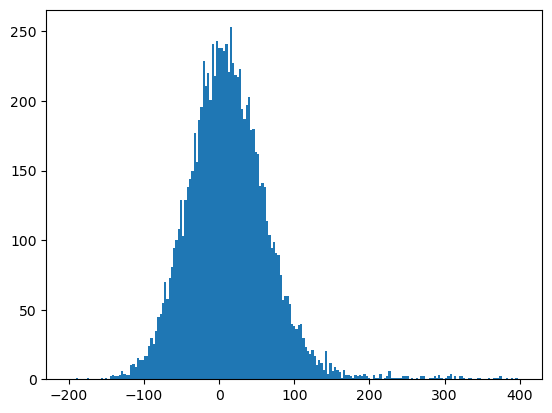

In [70]:
plt.hist(delta_reco_charge,
        bins=np.linspace(-200, 400, 200));

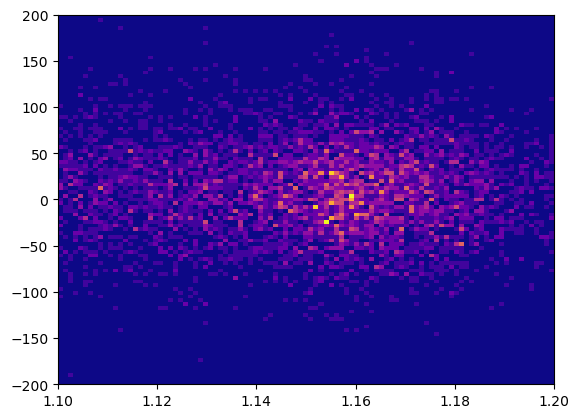

In [77]:
plt.hist2d(
    h5file.root.dl1.event.telescope.muon.tel_001[:]['muonring_radius'][:],
    delta_reco_charge,
    bins=[
        np.linspace( 1.1, 1.2, 100), 
        np.linspace( -200, 200, 100),
    ],
    cmap='plasma',
);

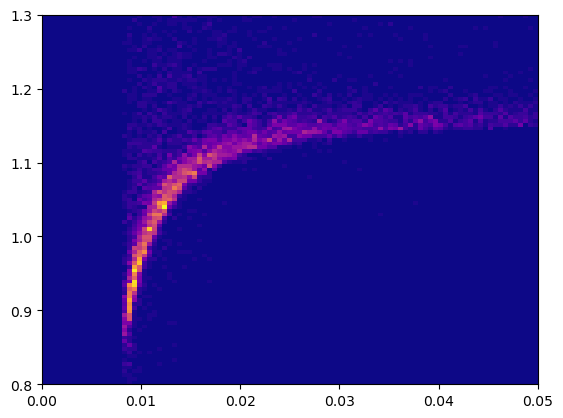

In [96]:
plt.hist2d(
    h5file.root.simulation.event.subarray.shower[:]['true_energy'][:],
    h5file.root.dl1.event.telescope.muon.tel_001[:]['muonring_radius'][:],
    bins=[
        np.linspace(0.0, 0.05, 100), 
        np.linspace(0.8, 1.3, 100),
    ],
    cmap='plasma',
);

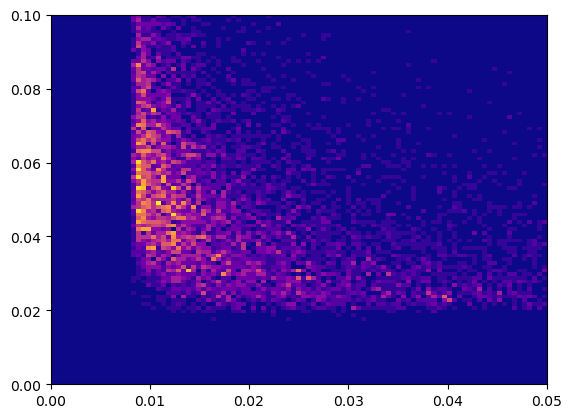

In [101]:
plt.hist2d(
    h5file.root.simulation.event.subarray.shower[:]['true_energy'][:],
    h5file.root.dl1.event.telescope.muon.tel_001[:]['muonefficiency_width'][:],
    bins=[
        np.linspace(0.0, 0.05, 100), 
        np.linspace(0.0, 0.1, 100),
    ],
    cmap='plasma',
);

700


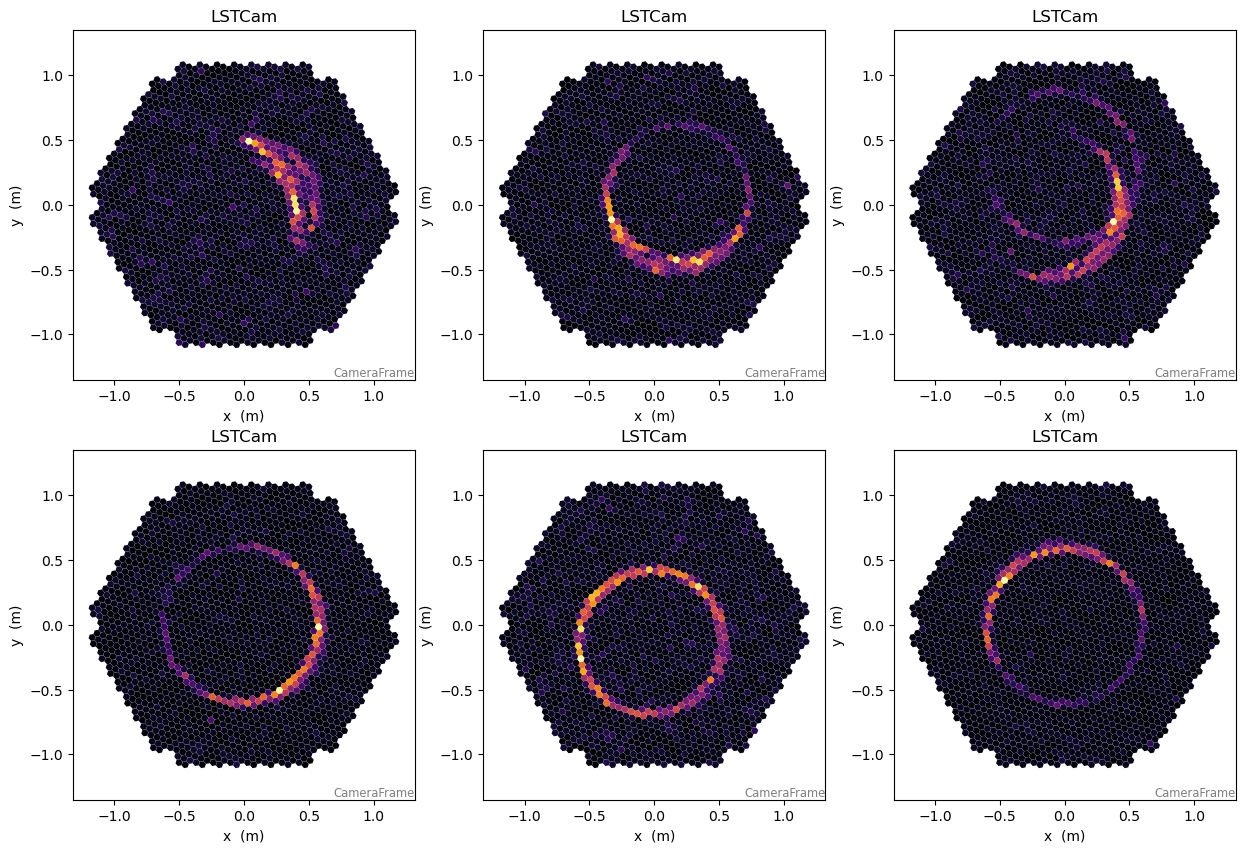

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][0],
    ax=ax[0][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][1],
    ax=ax[0][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][2],
    ax=ax[0][2])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][3],
    ax=ax[1][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][4],
    ax=ax[1][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image'][5],
    ax=ax[1][2])
print(h5file.root.dl1.event.telescope.images.tel_001[:]['event_id'][5])

In [11]:
rrrr=np.sqrt(h5file.root.simulation.event.subarray.shower[:]['true_core_x'] ** 2 + h5file.root.simulation.event.subarray.shower[:]['true_core_y'] ** 2)

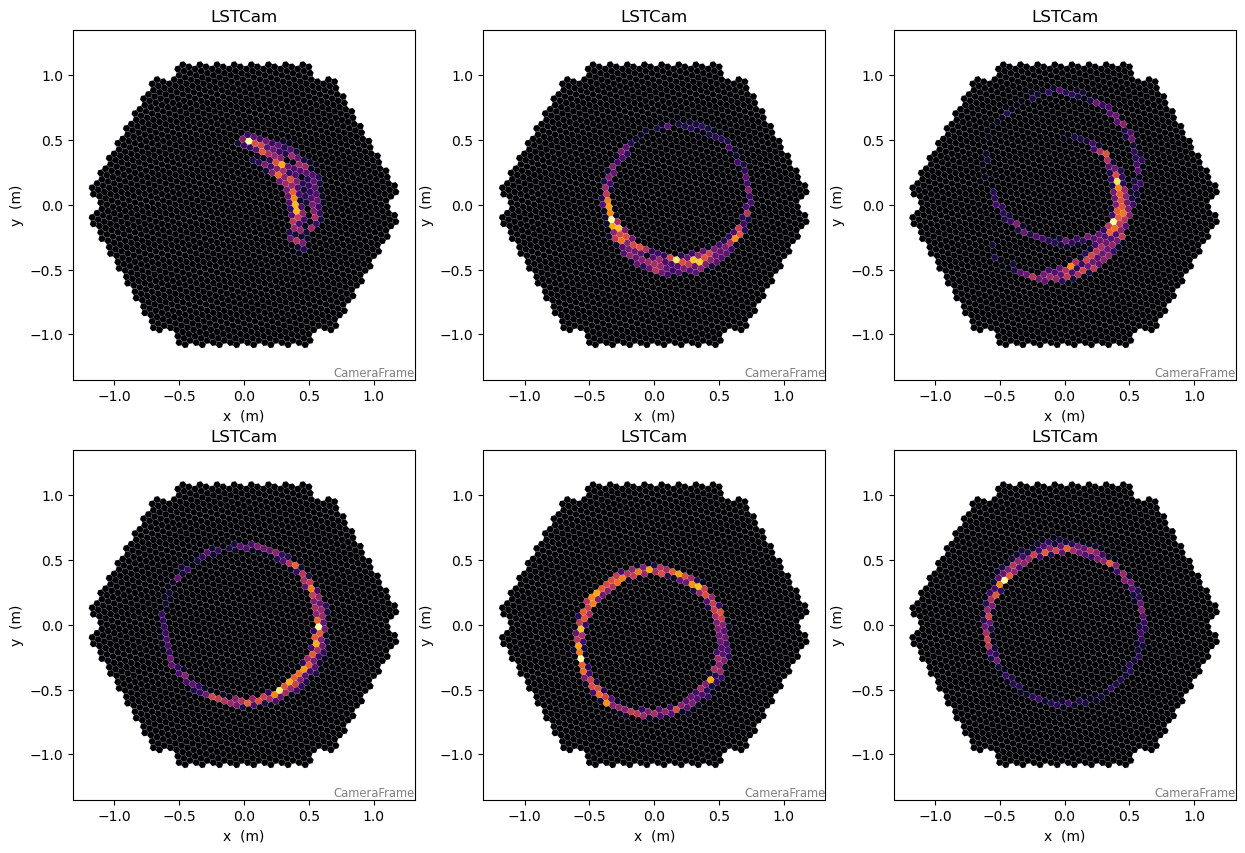

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][0],
    ax=ax[0][0])
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][1],
    ax=ax[0][1])
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][2],
    ax=ax[0][2])
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][3],
    ax=ax[1][0])
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][4],
    ax=ax[1][1])
disp = CameraDisplay(
    geom,
    h5file.root.simulation.event.telescope.images.tel_001[:]['true_image'][5],
    ax=ax[1][2])
#print(h5file.root.dl1.event.telescope.images.tel_001[:]['event_id'][5])

In [13]:
for i in np.arange(6):
    print(i+1," ",rrrr[i])

1   6.144713047859454
2   7.832515201912544
3   4.516804033133004
4   9.268177041026787
5   3.4591304063594133
6   8.50037671472832


In [14]:
optics

OpticsDescription(name=LST, size_type=LST, reflector_shape=PARABOLIC, equivalent_focal_length=28.00 m, effective_focal_length=29.31 m, n_mirrors=1, mirror_area=386.73 m2)

In [15]:
np.sqrt(optics.mirror_area/np.pi)

<Quantity 11.0950897 m>

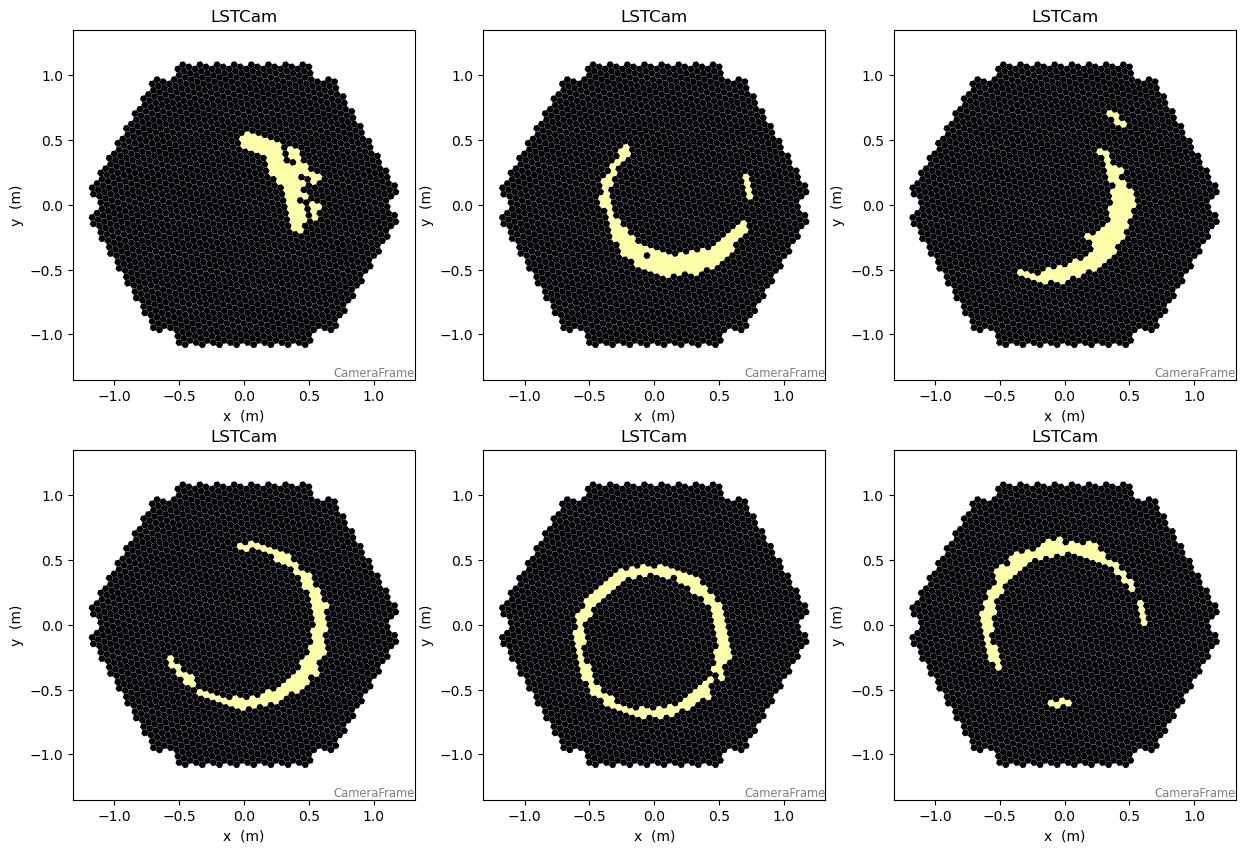

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][0],
    ax=ax[0][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][1],
    ax=ax[0][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][2],
    ax=ax[0][2])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][3],
    ax=ax[1][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][4],
    ax=ax[1][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['image_mask'][5],
    ax=ax[1][2])

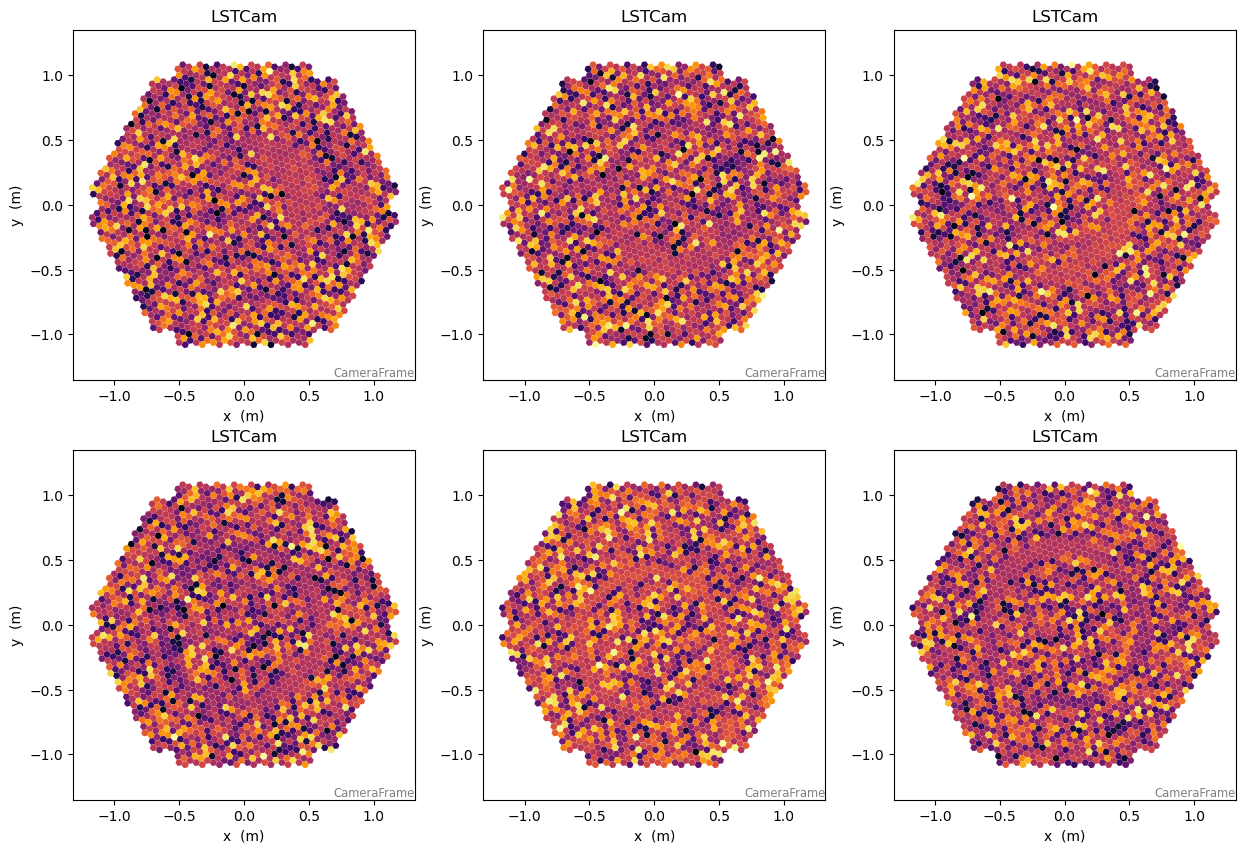

In [17]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][0],
    ax=ax[0][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][1],
    ax=ax[0][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][2],
    ax=ax[0][2])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][3],
    ax=ax[1][0])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][4],
    ax=ax[1][1])
disp = CameraDisplay(
    geom,
    h5file.root.dl1.event.telescope.images.tel_001[:]['peak_time'][5],
    ax=ax[1][2])